
[최신 시점 요약]
종가               : 3.73
RSI(14)            : 59.16
최근 5일 수익률     : -0.53%
거래량 비율         : 0.85배
최근 20일 고점 대비  : -1.32%
과매도 점수         : 0.00 / 100
판정               : 정상 조정

[최근 점수표]
            Close    Volume  RSI14  Ret_5d  Vol_Ratio  Drawdown_from_High  Price_Drop_Score  Volume_Score  RSI_Score  Drawdown_Score  Oversold_Score Oversold_Label
Date                                                                                                                                                               
2026-03-25   3.17  13551600  35.02   -4.52       0.96              -15.92             25.18          0.00      42.81           75.97           32.65      약한 과매도 후보
2026-03-26   3.15   9541300  34.38   -6.53       0.69              -14.17             45.28          0.00      44.63           65.70           40.30      약한 과매도 후보
2026-03-27   2.94  19287400  28.51   -9.54       1.38              -19.23             75.38         19.01      61.41           95.48           64.04 

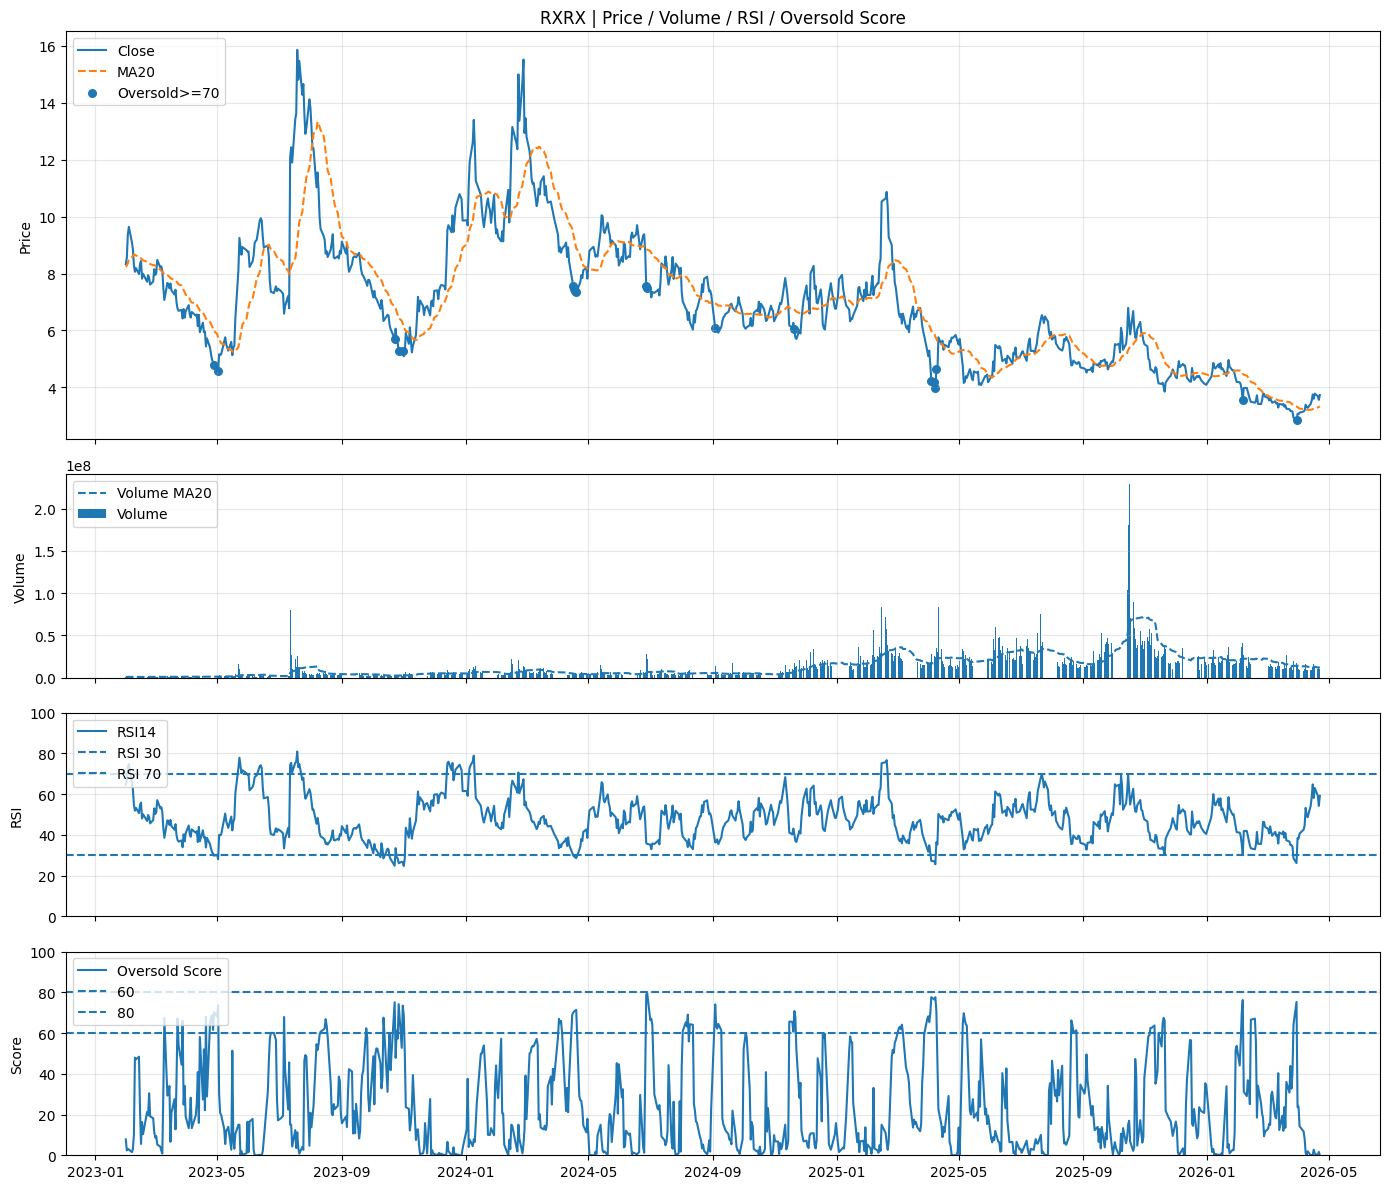

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


def compute_rsi(series: pd.Series, period: int = 14) -> pd.Series:
    """
    Wilder 방식 RSI 계산
    """
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))

    return rsi


def minmax_score(series: pd.Series, low: float, high: float, reverse: bool = False) -> pd.Series:
    """
    값을 0~100 점수로 변환
    reverse=False: 값이 클수록 점수 증가
    reverse=True : 값이 작을수록 점수 증가
    """
    clipped = series.clip(lower=min(low, high), upper=max(low, high))

    if not reverse:
        score = (clipped - low) / (high - low) * 100
    else:
        score = (high - clipped) / (high - low) * 100

    return score.clip(0, 100)


def build_oversold_indicator(
    ticker: str,
    start: str = "2022-01-01",
    end: str | None = None,
    price_drop_window: int = 5,
    volume_ma_window: int = 20,
    high_window: int = 20,
    rsi_period: int = 14
) -> pd.DataFrame:
    """
    주가/거래량/RSI 기반 과매도 점수 계산
    """
    df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)

    if df.empty:
        raise ValueError(f"데이터를 가져오지 못했습니다: {ticker}")

    # MultiIndex 방지
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    required_cols = ["Close", "Volume"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"필수 컬럼 누락: {col}")

    df = df[["Close", "Volume"]].copy()
    df.dropna(inplace=True)

    # 기본 지표
    df["MA20"] = df["Close"].rolling(20).mean()
    df["RSI14"] = compute_rsi(df["Close"], period=rsi_period)

    # 최근 n일 수익률
    df[f"Ret_{price_drop_window}d"] = df["Close"].pct_change(price_drop_window) * 100

    # 거래량 비율
    df[f"Vol_MA_{volume_ma_window}"] = df["Volume"].rolling(volume_ma_window).mean()
    df["Vol_Ratio"] = df["Volume"] / df[f"Vol_MA_{volume_ma_window}"]

    # 최근 고점 대비 낙폭
    df[f"Rolling_High_{high_window}"] = df["Close"].rolling(high_window).max()
    df["Drawdown_from_High"] = (
        (df["Close"] - df[f"Rolling_High_{high_window}"]) / df[f"Rolling_High_{high_window}"] * 100
    )

    # -----------------------------
    # 점수화
    # -----------------------------
    # 1) 하락률 점수: -2% ~ -12% 범위를 0~100으로 변환
    # 더 많이 빠질수록 점수 상승
    df["Price_Drop_Score"] = minmax_score(
        df[f"Ret_{price_drop_window}d"],
        low=-12,
        high=-2,
        reverse=True
    )

    # 2) 거래량 점수: 1.0배 ~ 3.0배 범위를 0~100
    df["Volume_Score"] = minmax_score(
        df["Vol_Ratio"],
        low=1.0,
        high=3.0,
        reverse=False
    )

    # 3) RSI 점수: 50 ~ 15 범위, 낮을수록 점수 상승
    df["RSI_Score"] = minmax_score(
        df["RSI14"],
        low=15,
        high=50,
        reverse=True
    )

    # 4) 낙폭 점수: -3% ~ -20%, 더 깊게 빠질수록 점수 상승
    df["Drawdown_Score"] = minmax_score(
        df["Drawdown_from_High"],
        low=-20,
        high=-3,
        reverse=True
    )

    # 최종 종합점수
    df["Oversold_Score"] = (
        0.40 * df["Price_Drop_Score"] +
        0.15 * df["Volume_Score"] +
        0.35 * df["RSI_Score"] +
        0.10 * df["Drawdown_Score"]
    ).clip(0, 100)

    # 등급
    conditions = [
        df["Oversold_Score"] < 30,
        (df["Oversold_Score"] >= 30) & (df["Oversold_Score"] < 60),
        (df["Oversold_Score"] >= 60) & (df["Oversold_Score"] < 80),
        df["Oversold_Score"] >= 80
    ]
    labels = [
        "정상 조정",
        "약한 과매도 후보",
        "의미 있는 과매도",
        "투매/패닉 가능성"
    ]
    df["Oversold_Label"] = np.select(conditions, labels, default="판정 불가")

    return df


def make_score_table(df: pd.DataFrame, tail_n: int = 15) -> pd.DataFrame:
    """
    최근 데이터 점수표 생성
    """
    cols = [
        "Close",
        "Volume",
        "RSI14",
        "Ret_5d",
        "Vol_Ratio",
        "Drawdown_from_High",
        "Price_Drop_Score",
        "Volume_Score",
        "RSI_Score",
        "Drawdown_Score",
        "Oversold_Score",
        "Oversold_Label"
    ]

    existing_cols = [c for c in cols if c in df.columns]
    table = df[existing_cols].tail(tail_n).copy()

    # 보기 좋게 반올림
    round_cols = [
        "Close", "RSI14", "Ret_5d", "Vol_Ratio", "Drawdown_from_High",
        "Price_Drop_Score", "Volume_Score", "RSI_Score",
        "Drawdown_Score", "Oversold_Score"
    ]
    for col in round_cols:
        if col in table.columns:
            table[col] = table[col].round(2)

    return table


def plot_oversold_dashboard(df: pd.DataFrame, ticker: str):
    """
    4패널 차트 출력
    """
    plot_df = df.dropna(subset=["RSI14", "Oversold_Score"]).copy()

    fig, axes = plt.subplots(
        4, 1, figsize=(14, 12), sharex=True,
        gridspec_kw={"height_ratios": [3, 1.5, 1.5, 1.5]}
    )

    # 1) 종가 + MA20 + 과매도 시점 표시
    axes[0].plot(plot_df.index, plot_df["Close"], label="Close")
    axes[0].plot(plot_df.index, plot_df["MA20"], label="MA20", linestyle="--")

    high_signal = plot_df["Oversold_Score"] >= 70
    axes[0].scatter(
        plot_df.index[high_signal],
        plot_df.loc[high_signal, "Close"],
        label="Oversold>=70",
        marker="o",
        s=30
    )
    axes[0].set_title(f"{ticker} | Price / Volume / RSI / Oversold Score")
    axes[0].set_ylabel("Price")
    axes[0].legend(loc="upper left")
    axes[0].grid(True, alpha=0.3)

    # 2) 거래량 + 평균거래량
    axes[1].bar(plot_df.index, plot_df["Volume"], label="Volume")
    if "Vol_MA_20" in plot_df.columns:
        axes[1].plot(plot_df.index, plot_df["Vol_MA_20"], label="Volume MA20", linestyle="--")
    axes[1].set_ylabel("Volume")
    axes[1].legend(loc="upper left")
    axes[1].grid(True, alpha=0.3)

    # 3) RSI
    axes[2].plot(plot_df.index, plot_df["RSI14"], label="RSI14")
    axes[2].axhline(30, linestyle="--", label="RSI 30")
    axes[2].axhline(70, linestyle="--", label="RSI 70")
    axes[2].set_ylabel("RSI")
    axes[2].set_ylim(0, 100)
    axes[2].legend(loc="upper left")
    axes[2].grid(True, alpha=0.3)

    # 4) 종합점수
    axes[3].plot(plot_df.index, plot_df["Oversold_Score"], label="Oversold Score")
    axes[3].axhline(60, linestyle="--", label="60")
    axes[3].axhline(80, linestyle="--", label="80")
    axes[3].set_ylabel("Score")
    axes[3].set_ylim(0, 100)
    axes[3].legend(loc="upper left")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def summarize_latest(df: pd.DataFrame):
    """
    최신 시점 요약 출력
    """
    latest = df.dropna().iloc[-1]

    print("\n[최신 시점 요약]")
    print(f"종가               : {latest['Close']:.2f}")
    print(f"RSI(14)            : {latest['RSI14']:.2f}")
    print(f"최근 5일 수익률     : {latest['Ret_5d']:.2f}%")
    print(f"거래량 비율         : {latest['Vol_Ratio']:.2f}배")
    print(f"최근 20일 고점 대비  : {latest['Drawdown_from_High']:.2f}%")
    print(f"과매도 점수         : {latest['Oversold_Score']:.2f} / 100")
    print(f"판정               : {latest['Oversold_Label']}")


if __name__ == "__main__":
    
    ticker = "RXRX"

    df = build_oversold_indicator(
        ticker=ticker,
        start="2023-01-01"
    )

    score_table = make_score_table(df, tail_n=20)

    summarize_latest(df)
    print("\n[최근 점수표]")
    print(score_table.to_string())

    plot_oversold_dashboard(df, ticker=ticker)